In [63]:
### Imports ###

import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/ryanhoffman/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
### Load Dataset ###

df = pd.read_parquet("../data/processed/ska_songs_clean.parquet")

ERA_ORDER = [
    "foundation",
    "expansion",
    "mainstream_peak",
    "post_peak",
    "revival",
    "modern"
]

print(f"Songs: {len(df)}")
print(f"Albums: {df["album"].nunique()}")

Songs: 1091
Albums: 83


In [25]:
### Convert Era to Ordered Categorical ###

df["era"] = pd.Categorical(
    df["era"],
    categories=ERA_ORDER,
    ordered=True
)

In [26]:
#########################################
### Structural Analysis               ###
#########################################

era_wc = df.groupby("era")["word_count"].agg(["count", "mean", "median"])
era_wc

/var/folders/gd/7vmq0h651d99wz_y83vt_g040000gn/T/ipykernel_8754/2985308527.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  era_wc = df.groupby("era")["word_count"].agg(["count", "mean", "median"])


,count,mean,median
era,,,
foundation,103,209.854369,204.0
expansion,278,249.928058,248.5
mainstream_peak,432,242.671296,227.0
post_peak,181,278.226519,243.0
revival,54,243.166667,242.5
modern,43,233.000000,224.0


/var/folders/gd/7vmq0h651d99wz_y83vt_g040000gn/T/ipykernel_8754/2600035806.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("era", sort=False)["word_count"].mean().plot(kind="bar")


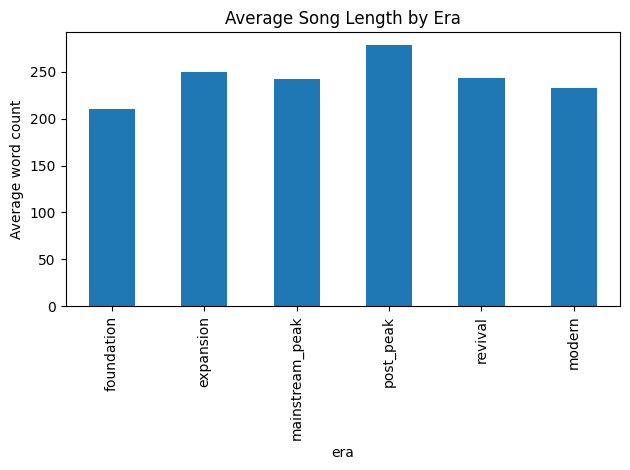

In [27]:
### Visualize the above findings ###

plt.figure()
df.groupby("era", sort=False)["word_count"].mean().plot(kind="bar")
plt.ylabel("Average word count")
plt.title("Average Song Length by Era")
plt.tight_layout()
plt.show()

In [28]:
### Lexical Diversity by Era ###
def lexical_diversity(text):
    words = text.split()
    if not words:
        return 0
    return len(set(words)) / len(words)

df["lex_div"] = df["lyrics_normalized"].apply(lexical_diversity)

In [29]:
era_ld = df.groupby("era")["lex_div"].agg(["mean", "median"])
era_ld

/var/folders/gd/7vmq0h651d99wz_y83vt_g040000gn/T/ipykernel_8754/950141915.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  era_ld = df.groupby("era")["lex_div"].agg(["mean", "median"])


,mean,median
era,,
foundation,0.464997,0.450980
expansion,0.404991,0.385016
mainstream_peak,0.424207,0.405945
post_peak,0.440099,0.423280
revival,0.418822,0.376009
modern,0.400764,0.400000


/var/folders/gd/7vmq0h651d99wz_y83vt_g040000gn/T/ipykernel_8754/411388666.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("era", sort=False)["lex_div"].mean().plot(kind="bar")


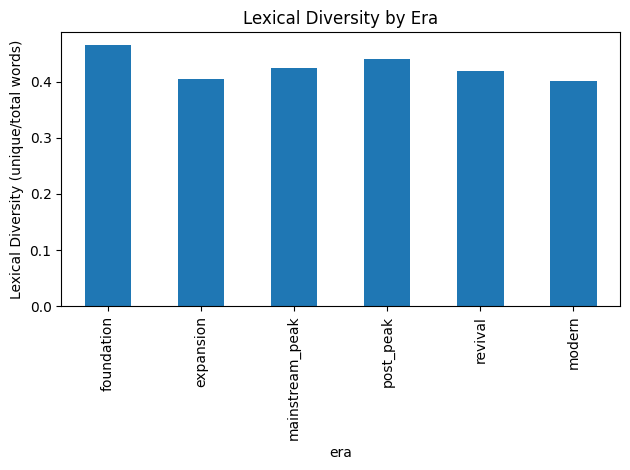

In [30]:
### Lexical Diversity Graph ###

plt.figure()
df.groupby("era", sort=False)["lex_div"].mean().plot(kind="bar")
plt.ylabel("Lexical Diversity (unique/total words)")
plt.title("Lexical Diversity by Era")
plt.tight_layout()
plt.show()

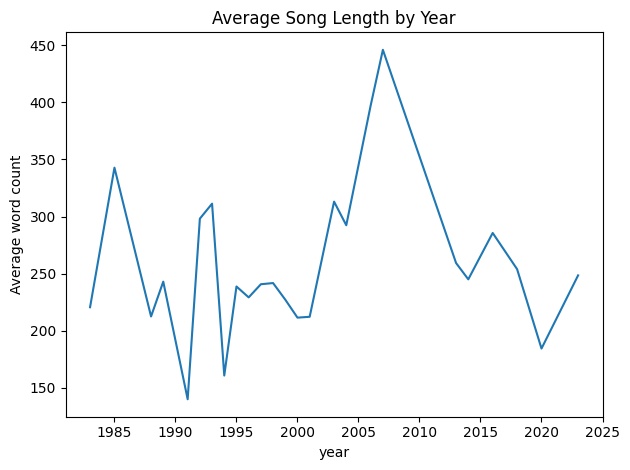

In [31]:
### Structural Trends Over Time ###
year_wc = df.groupby("year")["word_count"].mean()

plt.figure()
year_wc.plot()
plt.ylabel("Average word count")
plt.title("Average Song Length by Year")
plt.tight_layout()
plt.show()

In [32]:
#########################################
### Repetition Metrics                ###
#########################################

df["repetition"] = 1 - df["lex_div"]
df.groupby("era")["repetition"].mean().reindex(ERA_ORDER)

/var/folders/gd/7vmq0h651d99wz_y83vt_g040000gn/T/ipykernel_8754/2002598773.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("era")["repetition"].mean().reindex(ERA_ORDER)


era
foundation         0.535003
expansion          0.595009
mainstream_peak    0.575793
post_peak          0.559901
revival            0.581178
modern             0.599236
Name: repetition, dtype: float64

/var/folders/gd/7vmq0h651d99wz_y83vt_g040000gn/T/ipykernel_8754/526367274.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("era")["repetition"].mean().reindex(ERA_ORDER).plot(kind="bar")


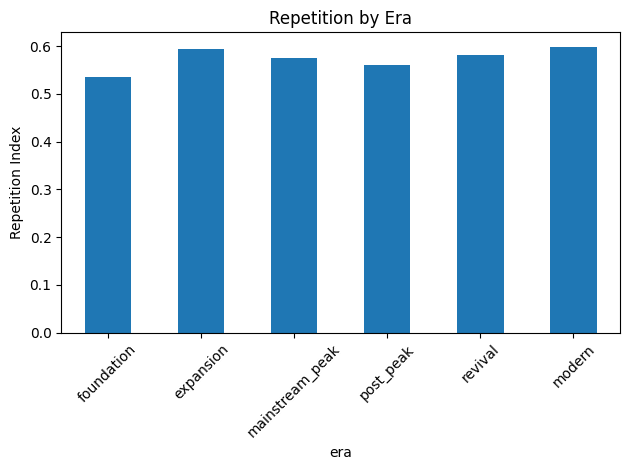

In [33]:
### Plot Repetition ###

plt.figure()
df.groupby("era")["repetition"].mean().reindex(ERA_ORDER).plot(kind="bar")
plt.ylabel("Repetition Index")
plt.title("Repetition by Era")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
#########################################
### Thematic Analysis                 ###
#########################################

# Starting with a political lens -

# TODO consider the inclusion of more words
POLITICAL_WORDS = [
    "police", "government", "state", "authority", "law", "prison", "system",
    "fight", "riot", "protest", "rebel", "revolution", "freedom", "justice", "rights",
    "war", "army", "soldier", "bomb", "gun"
]

In [35]:
def political_score(text):
    tokens = text.split()
    if not tokens:
        return 0
    count = sum(tokens.count(word) for word in POLITICAL_WORDS)
    return (count / len(tokens)) * 100

df["political_score"] = df["lyrics_normalized"].apply(political_score)

In [36]:
era_political = (
    df.groupby("era")["political_score"]
      .mean()
      .reindex(ERA_ORDER)
)

era_political

/var/folders/gd/7vmq0h651d99wz_y83vt_g040000gn/T/ipykernel_8754/1364490027.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("era")["political_score"]


era
foundation         0.273003
expansion          0.184104
mainstream_peak    0.252542
post_peak          0.258522
revival            0.396590
modern             0.228654
Name: political_score, dtype: float64

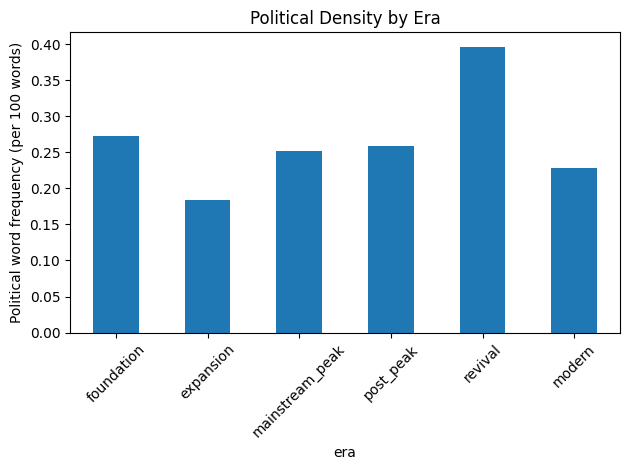

In [37]:
### Graph my political findings ###

plt.figure()
era_political.plot(kind="bar")
plt.ylabel("Political word frequency (per 100 words)")
plt.title("Political Density by Era")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
### Findings ###
# Hypothesis: The ska movement in America began under the same punk overtones that became intertwined with it in England's 2Tone.
#             As American ska grew into the ska-punk we know today, it lost it's political edge in favor of irony, absurdism, and silliness.
#             This was in line with the decline of political tones in American punk and pop punk and alt rock in general. Favoring more personal emotion than collective uprising

# Initial finding: This is not the case... Entirely. Foundational American ska was indeed very political. The expansion era that followed it also declined in political message as expected.
#                  However the political messaging did not continue to decline. Expansion era proved to be the lowest political word frequency of any era.
#                  Mainstream peak and post peak eras saw a similar return to politically frequent (tm) lyrics, not quite as high as foundation, but notably higher than expansion.
#                  The real shock was that revival era ska-punk had the most politically frequent lyrics of any era, surpassing foundations: 0.27 all the way up to 0.39.
#                  Following the revival era, modern era ska drops drastically, but not to the expansion era lows. Instead settling just below the peak of ska in America.

In [40]:
### Is the revival data skewed by only a few bands? ###
df.groupby("era")["political_score"].std().reindex(ERA_ORDER)

/var/folders/gd/7vmq0h651d99wz_y83vt_g040000gn/T/ipykernel_8754/3475779036.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("era")["political_score"].std().reindex(ERA_ORDER)


era
foundation         0.757199
expansion          0.780722
mainstream_peak    0.678316
post_peak          0.949176
revival            0.710914
modern             0.730623
Name: political_score, dtype: float64

In [41]:
### Above Findings: ###
# Post-Peak has by far the highest standard deviation. This means that there was a wide spread among bands being highly political and not political.
# This can potentially be explained by scenes splintering and a lack of overall centralization.

# Mainstream-Peak had the smallest standard deviation, but we also know that it is by far the most represented era by song count in the dataset (432).
# This might mean that while the mainstream peak isn't wildly political, it also isn't not political. There was a distinct political thread that ran through mainstream peak ska and it was uniform across everything.

# Revival era ska has a high mean with moderate standard deviation. This means that revival bands are more uniformly political.

In [44]:
#########################################
### Pronoun Shift                     ###
#########################################

COLLECTIVE_PRONOUNS = ["we", "us", "our", "ours"]
INDIVIDUAL_PRONOUNS = ["i", "me", "my", "mine"]

def pronoun_score(text, pronoun_list):
    tokens = text.split()
    if not tokens:
        return 0
    count = sum(tokens.count(p) for p in pronoun_list)
    return (count / len(tokens)) * 100

In [45]:
df["collective_score"] = df["lyrics_normalized"].apply(
    lambda x: pronoun_score(x, COLLECTIVE_PRONOUNS)
)

df["individual_score"] = df["lyrics_normalized"].apply(
    lambda x: pronoun_score(x, INDIVIDUAL_PRONOUNS)
)

In [46]:
era_pronouns = df.groupby("era")[["collective_score", "individual_score"]] \
                 .mean() \
                 .reindex(ERA_ORDER)

era_pronouns

/var/folders/gd/7vmq0h651d99wz_y83vt_g040000gn/T/ipykernel_8754/1796077097.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  era_pronouns = df.groupby("era")[["collective_score", "individual_score"]] \


,collective_score,individual_score
era,,
foundation,1.159394,5.171164
expansion,1.082141,7.641861
mainstream_peak,0.918954,7.701789
post_peak,1.474200,7.592054
revival,2.076576,4.863793
modern,2.735338,6.746832


<Figure size 640x480 with 0 Axes>

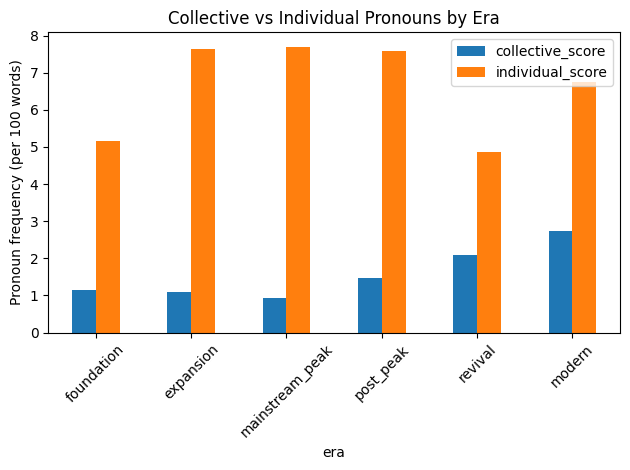

In [47]:
### Plot Collective and Indiviual Scores

plt.figure()
era_pronouns.plot(kind="bar")
plt.ylabel("Pronoun frequency (per 100 words)")
plt.title("Collective vs Individual Pronouns by Era")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
### Findings
# Hypothesis: Foundational ska was more collective in pronoun. Going alongside my hypothesis of early ska being more political, I would expect there to be more collective pronoun language.
#             I would have expected peak through to modern to be more individual.
#
#             Following the findings above, my hypothesis would have changed though. 
#             As we learned that foundation was indeed very political, it took a dip in the expansion era, but then rebounded in an even bigger way in the revival era.
#             With this in mind, I would expect collective pronoun use to mirror the political lyric pattern: common in foundation, dip in expansion/mainstream, and spike in revival.
#             As far as Individual pronoun use is concerned, I would expect it to be inversely related to collective pronoun use. If you are using we, you are not using me.
#             I would expect the mainstream and post peak eras to be the most individual in language. With foundation and revival to be the least.
#
# Analysis: What we have seen is partially in-line with the hypothesis. To start with the findings that were in line with expectations:
#           Revival had an incredibly high collective score. Mainstream peak had the lowest collective score. Foundation and revival had the lowest individual scores.
#           This is about it for hypothesis accuracy. What I found was very interesting. Foundation had one of the lowest collective scores and individual scores.
#           Does this mean that foundational era ska used the least pronouns? This feels odd.
#           Expansion, mainstream peak, and post peak eras of ska had by far the highest individual scores. The commercialization of ska saw a huge rise in individualism. This makes sense.
#           Revival saw a huge dip in individual language and a huge rise in collective language. This was expected. What wasn't expected though, was what I found in modern era ska.
#           Modern era ska had the highest overall colletive pronoun useage. It also saw a huge rise from revival in individual pronoun useage. Not as high as the mainstream peak's, but still quite high.
#           This tells us that as the commercialization of ska declined, collective language became increasingly used.


In [ ]:
### Ratio of Indivdual pronoun use compared to Collective pronoun ###
era_means = df.groupby("era")[["collective_score","individual_score"]] \
              .mean() \
              .reindex(ERA_ORDER)

era_means["indiv_collect_ratio"] = (
    era_means["individual_score"] / era_means["collective_score"]
)

era_means

/var/folders/gd/7vmq0h651d99wz_y83vt_g040000gn/T/ipykernel_8754/3822486565.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  era_means = df.groupby("era")[["collective_score","individual_score"]] \


,collective_score,individual_score,indiv_collect_ratio
era,,,
foundation,1.159394,5.171164,4.460230
expansion,1.082141,7.641861,7.061797
mainstream_peak,0.918954,7.701789,8.381036
post_peak,1.474200,7.592054,5.149950
revival,2.076576,4.863793,2.342218
modern,2.735338,6.746832,2.466544


In [ ]:
### Standard Deviation by Era ###
df.groupby("era")[["collective_score","individual_score"]] \
  .std() \
  .reindex(ERA_ORDER)

/var/folders/gd/7vmq0h651d99wz_y83vt_g040000gn/T/ipykernel_8754/1117134793.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("era")[["collective_score","individual_score"]] \


,collective_score,individual_score
era,,
foundation,2.230348,5.172392
expansion,2.517762,4.851745
mainstream_peak,1.892776,5.115033
post_peak,2.085406,4.300216
revival,3.617239,4.681017
modern,3.496513,5.510940


In [51]:
### Album level check ###
album_pronouns = (
    df.groupby(["era","album"])[["collective_score","individual_score"]]
      .mean()
      .reset_index()
)

album_pronouns.groupby("era")[["collective_score","individual_score"]] \
              .mean() \
              .reindex(ERA_ORDER)

/var/folders/gd/7vmq0h651d99wz_y83vt_g040000gn/T/ipykernel_8754/2848988839.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["era","album"])[["collective_score","individual_score"]]
/var/folders/gd/7vmq0h651d99wz_y83vt_g040000gn/T/ipykernel_8754/2848988839.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  album_pronouns.groupby("era")[["collective_score","individual_score"]] \


,collective_score,individual_score
era,,
foundation,1.162314,5.040685
expansion,1.080539,7.830575
mainstream_peak,0.931869,7.740696
post_peak,1.481045,7.668125
revival,2.016193,4.942273
modern,2.700235,6.816823


In [53]:
### Findings after checks ###
# The ratio is how many individual pronouns appear per collective pronoun. This tells us:
# 1.  (8.38) Mainstream Peak is the most individualistic, the least collective, and the strongest departure from communal language.
# 2.  (7.06) Expansion is also highly individual, meaning the shift to highly individual happens before the mainstream peak. This suggest a relationship with commercial scaling.
# 3.  (5.15) Post Peak saw a partial rebalancing as individual pronoun use fell while collective pronoun use rose. This proved to be the start of a shift.
# 4.  (2.3/2.4) Revival/Modern saw a dramatic rise in collective pronoun use.
#
# A note on the standard deviation findings and album analysis. Album analysis is simple: the collective and individual scores corresponded to the song level findings, meaning that particular albums aren't skewing the data.
# As for the standard deviation, the numbers suggest that revival and modern have much higher variance. This is in line with the political theme analysis I did earlier for these eras.
# Without checking particular albums, this shows that some bands lean super heavily into collective voice, while others lean individual in narrative.

In [54]:
#########################################
### Emotional Language Usage          ###
#########################################

EMOTIONAL_WORDS = [
    "love", "heart", "miss", "baby", "girl", "boy", "kiss",
    "alone", "lonely", "cry", "tears", "hurt", "broken", "pain", "sad", "fear"
]

def emotional_score(text):
    tokens = text.split()
    if not tokens:
        return 0
    count = sum(tokens.count(word) for word in EMOTIONAL_WORDS)
    return (count / len(tokens)) * 100

df["emotional_score"] = df["lyrics_normalized"].apply(emotional_score)

In [55]:
era_emotional = (
    df.groupby("era")["emotional_score"]
      .mean()
      .reindex(ERA_ORDER)
)

era_emotional

/var/folders/gd/7vmq0h651d99wz_y83vt_g040000gn/T/ipykernel_8754/1074405565.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("era")["emotional_score"]


era
foundation         0.734762
expansion          0.709665
mainstream_peak    0.991679
post_peak          0.681949
revival            0.499490
modern             0.648023
Name: emotional_score, dtype: float64

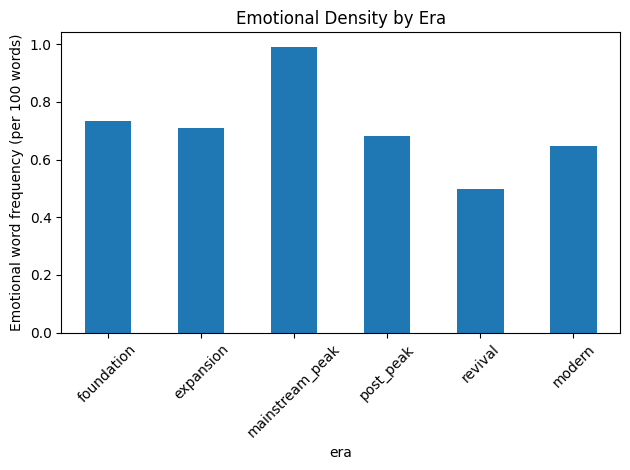

In [56]:
### Graph Findings ###

plt.figure()
era_emotional.plot(kind="bar")
plt.ylabel("Emotional word frequency (per 100 words)")
plt.title("Emotional Density by Era")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [57]:
### Hypothesis At-First vs Now ###
# Hypothesis: I initially believed that ska would reflect my impression of how american punk/pop punk evolved: initially collective and anti-establishment,
#             and then increasingly personal and emotional in nature.
#
# Hypothesis now: After seeing the previous analyses on political and collective pronoun axes, I now believe that ska does not follow the pop-punk path.
#                 The indications of some bands in the revival/modern eras being more collective and politically oriented (albeit with high variance) lead me to believe that commercial success drives individuality and thus emotional lyrics.
#                 I expect to see emotion roughly correlate with individual pronoun use.
#
# Findings: Mainstream saw a spike in emotional language. Post peak saw a big decline that continued into revival era, and then modern era saw a rebalance to pre mainstream levels.


In [58]:
### Check correlation (song level) ###
df[["individual_score", "emotional_score"]].corr()

,individual_score,emotional_score
individual_score,1.000000,0.106663
emotional_score,0.106663,1.000000


In [59]:
### Analysis ###
# The number 0.106663 means that these scores are not closely related. The useage of individual pronouns and the useage of emotional words are not strongly correlated.
# Something else is happening that is driving these trends. The trends are happening in parallel.

In [60]:
df.groupby("commercial_tier")["emotional_score"].mean()

commercial_tier
0    0.268819
1    0.854073
2    0.739181
3    0.845757
Name: emotional_score, dtype: float64

In [61]:
df.groupby("commercial_tier")["individual_score"].mean()

commercial_tier
0    4.274080
1    7.360007
2    7.202351
3    7.180137
Name: individual_score, dtype: float64

In [62]:
### Analysis ###
# Commercially successful albums are both more individual and emotional.

In [64]:
#########################################
### Sentiment Analysis of Tone        ###
#########################################

df["sentiment"] = df["lyrics_clean"].apply(lambda x: sia.polarity_scores(x)["compound"])

In [ ]:
### Check sentiment by commercial tier ###
df.groupby("commercial_tier")["sentiment"].mean()

/var/folders/gd/7vmq0h651d99wz_y83vt_g040000gn/T/ipykernel_8754/4023076756.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("era")["sentiment"].mean().reindex(ERA_ORDER)


commercial_tier
0   -0.215980
1   -0.045969
2    0.049411
3    0.225766
Name: sentiment, dtype: float64

In [66]:
### Standard Deviation Check ###
df.groupby("commercial_tier")["sentiment"].std()

commercial_tier
0    0.849239
1    0.846102
2    0.877870
3    0.884067
Name: sentiment, dtype: float64

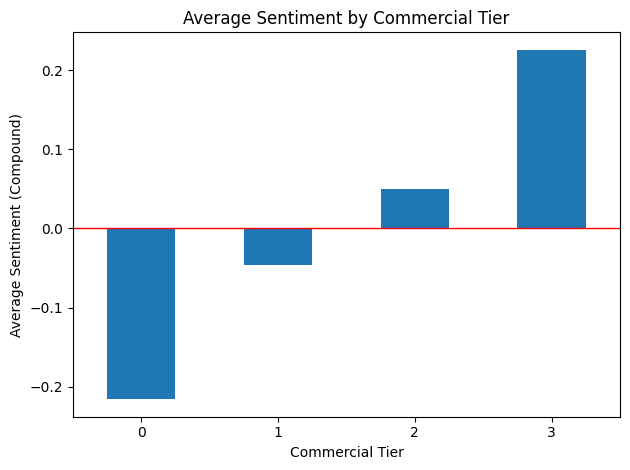

In [71]:
### Graphing sentiment mean across commercial tiers ###

# Ensure correct order
TIER_ORDER = [0, 1, 2, 3]

sent_by_tier = (
    df.groupby("commercial_tier")["sentiment"]
    .mean()
    .reindex(TIER_ORDER)
)

plt.figure()
sent_by_tier.plot(kind="bar")
plt.axhline(0, color='red', linewidth=1)
plt.ylabel("Average Sentiment (Compound)")
plt.xlabel("Commercial Tier")
plt.title("Average Sentiment by Commercial Tier")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
### Findings ###
# Albums that were successful were increasingly positive in tone. The most successful albums were the ones that were the most positive

In [74]:
### Check sentiment by era ###
df.groupby("era")["sentiment"].mean().reindex(ERA_ORDER)


/var/folders/gd/7vmq0h651d99wz_y83vt_g040000gn/T/ipykernel_8754/2800611922.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("era")["sentiment"].mean().reindex(ERA_ORDER)


era
foundation        -0.049915
expansion          0.104994
mainstream_peak    0.097559
post_peak         -0.189685
revival           -0.195030
modern            -0.416212
Name: sentiment, dtype: float64

/var/folders/gd/7vmq0h651d99wz_y83vt_g040000gn/T/ipykernel_8754/2772832289.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("era")["sentiment"]


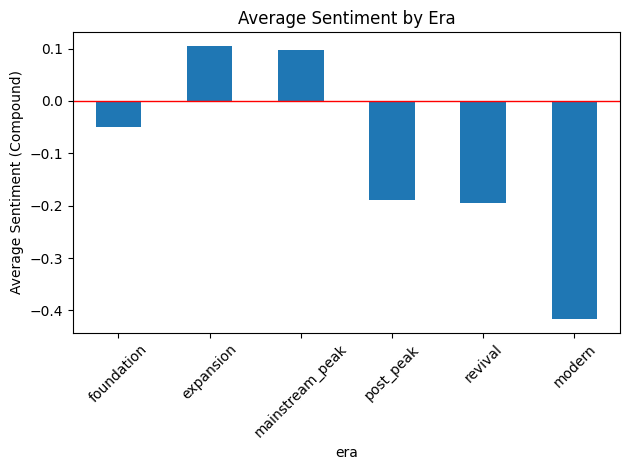

In [75]:
sent_by_era = (
    df.groupby("era")["sentiment"]
    .mean()
    .reindex(ERA_ORDER)
)

plt.figure()
sent_by_era.plot(kind="bar")
plt.axhline(0, color='red', linewidth=1)
plt.ylabel("Average Sentiment (Compound)")
plt.title("Average Sentiment by Era")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [76]:
### Findings ###
# Positive lyrics were most common in the expansion and mainstream peak eras of ska. 
# Modern songs were the most negative of any era, indicating that as time passed and ska fell out of popularity, its lyrics returned to more political, confrontational, communal, and negative tones.
